# Eniac A/B Test: Which Button Converts Best?

Eniac tested four versions of the call-to-action button on its homepage:

| Version | Color | Text |
|---|---|---|
| A (current) | white | SHOP NOW |
| B | red | SHOP NOW |
| C | white | SEE DEALS |
| D | red | SEE DEALS |

**Primary metric:** click-through rate (CTR) = clicks on the button / visits to the homepage.
A version is only considered superior if its CTR difference is statistically significant.

**Hypotheses**
- H₀: All four versions have the same CTR.
- H₁: At least one version has a different CTR.

**Test design:** α = 0.05, power = 80%, minimum detectable effect (MDE) = 20%, baseline CTR ≈ 2%, ~7,142 visits per day.
The test ran for 14 days (2021-11-02 to 2021-11-16) to cover two full business cycles.

## 1. Setup

In [19]:
import re
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import chi2_contingency
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_confint, proportion_effectsize

In [20]:
# Plot style (set_theme resets fonts, so the font family comes after it)
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["font.family"] = "monospace"

DARK_RED = "#8B0000"

# Visual style per version: fill color, hatch pattern (= button text), hatch color, legend label
STYLES = {
    "a": {"fill": "white",  "hatch": "",   "hatch_color": "black", "label": "A: white, SHOP NOW"},
    "b": {"fill": DARK_RED, "hatch": "",   "hatch_color": "white", "label": "B: red, SHOP NOW"},
    "c": {"fill": "white",  "hatch": "//", "hatch_color": "black", "label": "C: white, SEE DEALS"},
    "d": {"fill": DARK_RED, "hatch": "//", "hatch_color": "white", "label": "D: red, SEE DEALS"},
}

VERSIONS = ["a", "b", "c", "d"]
ALPHA = 0.05
POWER = 0.8
VISITS_PER_DAY = 7142


def draw_styled_bar(ax, x, height, version):
    """Draw one bar in the style of its version: fill + hatch first, black outline on top."""
    s = STYLES[version]
    ax.bar(x, height, color=s["fill"], edgecolor=s["hatch_color"], hatch=s["hatch"], linewidth=0, zorder=2)
    ax.bar(x, height, color="none", edgecolor="black", linewidth=1.2, zorder=3)


def version_legend(ax, versions):
    """Add a legend below the plot with one entry per version."""
    handles = [
        Patch(facecolor=STYLES[v]["fill"],
              edgecolor=STYLES[v]["hatch_color"] if STYLES[v]["fill"] == DARK_RED else "black",
              hatch=STYLES[v]["hatch"], label=STYLES[v]["label"])
        for v in versions
    ]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.15),
              ncol=2, fontsize=9, framealpha=0.9)

## 2. Load the data

Each CSV is an export from a click-tracking tool: one row per clickable element on the homepage.
The button we care about is a single row (`Name` = "SHOP NOW" or "SEE DEALS").
The total number of visits is not a column of its own but is stored as text in `Snapshot information`.

In [21]:
dfs = {v: pd.read_csv(f"../data/eniac_{v}.csv") for v in VERSIONS}

dfs["a"].head()

,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,269,True,Homepage Version A - white SHOP NOW • http...
1,25,div,mySidebar,309,True,created 2021-09-14 • 14 days 0 hours 34 mi...
2,4,a,Mac,279,True,NaN
3,69,a,iPhone,246,True,NaN
4,105,a,Accessories,1235,True,NaN


In [22]:
# The snapshot info (version, creation date, duration, visits) only appears in two rows per file
for v in VERSIONS:
    print(v.upper(), dfs[v]["Snapshot information"].dropna().tolist())

A ['Homepage Version A - white SHOP NOW   •   https://eniac.com/index-a.php', 'created 2021-09-14   •   14 days 0 hours 34 mins   •   25326 visits, 23174 clicks']
B ['Homepage Version B - red SHOP NOW   •   https://eniac.com/index-b.php', 'created 2021-10-27   •   14 days 0 hours 34 mins   •   24747 visits, 22407 clicks']
C ['Homepage Version C - white SEE DEALS   •   https://eniac.com/index-c.php', 'created 2021-10-27   •   14 days 0 hours 34 mins   •   24876 visits, 23031 clicks']
D ['Homepage Version D - red SEE DEALS   •   https://eniac.com/index-d.php', 'created 2021-10-27   •   14 days 0 hours 34 mins   •   25233 visits, 22743 clicks']


Note: Version A's snapshot was created on 2021-09-14, versions B–D on 2021-10-27.
All four report the same duration (14 days), so this most likely reflects when the pages were set up, not the test period itself.

## 3. Click-through rate per version

In [23]:
def extract_visits(df):
    """Pull the number of visits out of the snapshot text, e.g. '... 25326 visits, 23174 clicks'."""
    texts = df["Snapshot information"].dropna().tolist()
    info = [t for t in texts if "visits" in t][0]
    return int(re.search(r"([\d,]+) visits", info).group(1).replace(",", ""))


def extract_button_clicks(df):
    """Clicks on the tested button, whichever text it has in this version."""
    row = df[df["Name"].isin(["SHOP NOW", "SEE DEALS"])]
    return int(row["No. clicks"].iloc[0])


summary = pd.DataFrame({
    "version": VERSIONS,
    "visits": [extract_visits(dfs[v]) for v in VERSIONS],
    "clicks": [extract_button_clicks(dfs[v]) for v in VERSIONS],
})
summary["no_clicks"] = summary["visits"] - summary["clicks"]
summary["ctr"] = summary["clicks"] / summary["visits"]

# 95 % confidence interval for each CTR (Wilson method, more accurate for small proportions)
summary["ci_low"], summary["ci_high"] = proportion_confint(
    summary["clicks"], summary["visits"], alpha=ALPHA, method="wilson"
)

summary

,version,visits,clicks,no_clicks,ctr,ci_low,ci_high
0,a,25326,512,24814,0.020216,0.018554,0.022024
1,b,24747,281,24466,0.011355,0.010109,0.012753
2,c,24876,527,24349,0.021185,0.019468,0.023050
3,d,25233,193,25040,0.007649,0.006646,0.008801


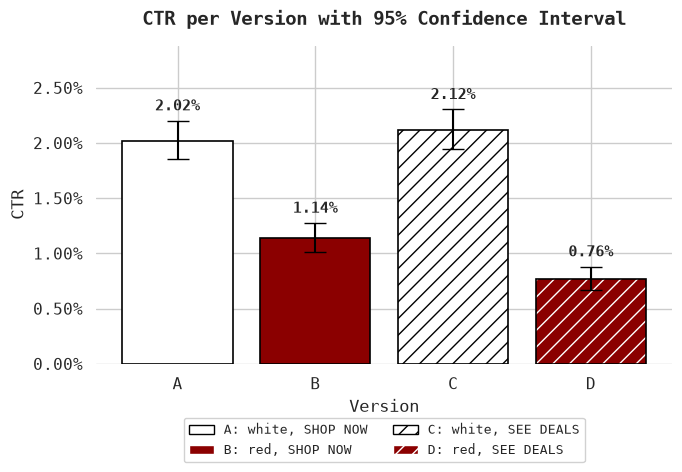

In [24]:
x_pos = np.arange(len(summary))
fig, ax = plt.subplots(figsize=(7, 5))

for x, row in zip(x_pos, summary.itertuples()):
    draw_styled_bar(ax, x, row.ctr, row.version)
    ax.errorbar(x, row.ctr, yerr=[[row.ctr - row.ci_low], [row.ci_high - row.ctr]],
                fmt="none", ecolor="black", elinewidth=1.5, capsize=8, zorder=4)
    ax.text(x, row.ci_high + 0.0006, f"{row.ctr:.2%}", ha="center", va="bottom",
            fontsize=11, fontweight="bold")

ax.set_xticks(x_pos)
ax.set_xticklabels([v.upper() for v in summary["version"]])
ax.set_title("CTR per Version with 95% Confidence Interval", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Version")
ax.set_ylabel("CTR")
ax.set_ylim(0, summary["ci_high"].max() * 1.25)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
sns.despine(left=True, bottom=True)
version_legend(ax, VERSIONS)

plt.tight_layout()
plt.show()

**First look**
1. **CTR per version:** A 2.02% · B 1.14% · C 2.12% · D 0.76%
2. **Highest CTR:** Version C (white, SEE DEALS), just ahead of the current version A.
3. **Conclusive?** Not yet. White buttons clearly outperform red ones, and their confidence intervals don't overlap.
   The intervals of A and C, however, overlap heavily. A significance test is needed.

## 4. Chi-square test across all versions

Each visit either led to a click or not. The contingency table counts both outcomes per version.
The chi-square test checks how likely differences this large would be if all versions had the same CTR (H₀).

In [25]:
contingency = summary.set_index("version")[["clicks", "no_clicks"]]
contingency

,clicks,no_clicks
version,,
a,512,24814
b,281,24466
c,527,24349
d,193,25040


In [26]:
result = chi2_contingency(contingency)

print(f"Chi-square statistic: {result.statistic:.2f}")
print(f"Degrees of freedom:   {result.dof}")
print(f"p-value:              {result.pvalue:.2e}")
print(f"Reject H0 (p < {ALPHA})? {result.pvalue < ALPHA}")

Chi-square statistic: 224.02
Degrees of freedom:   3
p-value:              2.72e-48
Reject H0 (p < 0.05)? True


**Interpretation:** p ≈ 2.7 × 10⁻⁴⁸, far below α = 0.05. We reject H₀: the CTR depends on the version.
This tells us that *some* versions differ, but not *which* ones. That requires pairwise post-hoc tests.

## 5. Post-hoc: pairwise chi-square tests with Bonferroni correction

Four versions give six pairs. Running six tests at α = 0.05 each raises the risk of at least one false positive
to about 1 − 0.95⁶ ≈ 26%. The Bonferroni correction compensates by dividing α by the number of comparisons.

In [27]:
pairs = list(combinations(VERSIONS, 2))
alpha_corrected = ALPHA / len(pairs)

pairwise = []
for v1, v2 in pairs:
    p = chi2_contingency(contingency.loc[[v1, v2]]).pvalue
    pairwise.append({
        "comparison": f"{v1.upper()} vs {v2.upper()}",
        "p_value": p,
        "significant": p < alpha_corrected,
    })

pairwise_df = pd.DataFrame(pairwise)
print(f"Bonferroni-corrected alpha: {alpha_corrected:.4f}")
pairwise_df

Bonferroni-corrected alpha: 0.0083


,comparison,p_value,significant
0,A vs B,2.673088e-15,True
1,A vs C,4.648421e-01,False
2,A vs D,3.080898e-33,True
3,B vs C,6.955480e-18,True
4,B vs D,2.357337e-05,True
5,C vs D,6.450501e-37,True


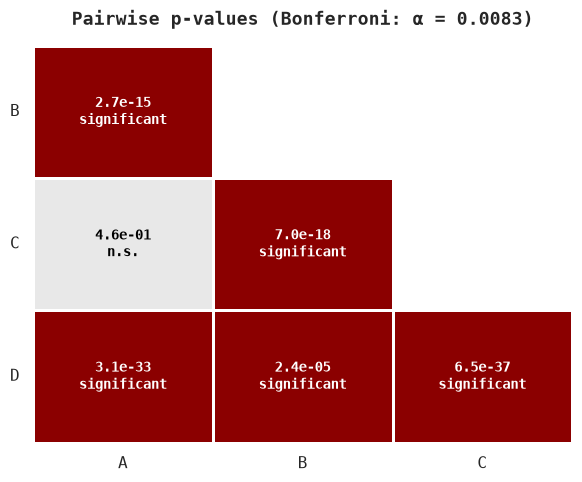

In [28]:
# Lower-triangle heatmap of the pairwise results
labels = [v.upper() for v in VERSIONS]
p_matrix = pd.DataFrame(np.nan, index=labels, columns=labels)
for row in pairwise_df.itertuples():
    v1, v2 = row.comparison.split(" vs ")
    p_matrix.loc[v1, v2] = p_matrix.loc[v2, v1] = row.p_value

p_trim = p_matrix.iloc[1:, :-1]                                   # drop empty row A and column D
mask = np.triu(np.ones_like(p_trim, dtype=bool), k=1)            # show each pair only once
is_sig = p_trim < alpha_corrected
annot = p_trim.map(lambda p: "" if pd.isna(p)
                   else f"{p:.1e}\n{'significant' if p < alpha_corrected else 'n.s.'}")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(is_sig, mask=mask, annot=annot, fmt="", cmap=["#E8E8E8", DARK_RED],
            cbar=False, linewidths=2, linecolor="white",
            annot_kws={"fontsize": 10, "fontweight": "bold"}, ax=ax)
ax.grid(False)

# White text on dark red, black text on grey
for text, sig in zip(ax.texts, is_sig.values[~mask]):
    text.set_color("white" if sig else "black")

ax.set_title(f"Pairwise p-values (Bonferroni: α = {alpha_corrected:.4f})",
             fontsize=13, fontweight="bold", pad=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation**
- All pairs differ significantly **except A vs C** (p ≈ 0.465).
- White beats red in every comparison. Among the red buttons, B (SHOP NOW) beats D (SEE DEALS).
- There is **no single winner**: C's lead over A cannot be distinguished from chance.

## 6. Power analysis: how long would we need to test A vs C?

"Not significant" does not mean "proven equal". The test was designed to detect differences of at least 20%,
while A and C differ by less than 5%. The power analysis estimates the sample size needed to detect that difference.

In [29]:
power_analysis = NormalIndPower()

ctr_a = summary.set_index("version").loc["a", "ctr"]
ctr_c = summary.set_index("version").loc["c", "ctr"]
observed_uplift = ctr_c / ctr_a - 1

# Original test design: baseline 2 %, MDE 20 %
n_design = power_analysis.solve_power(effect_size=proportion_effectsize(0.02 * 1.2, 0.02),
                                      alpha=ALPHA, power=POWER)
print(f"Original design: {n_design:,.0f} visits per version "
      f"→ {n_design / (VISITS_PER_DAY / 4):.0f} days with 4 versions")

# Observed difference between A and C (Cohen's h)
effect_ac = proportion_effectsize(ctr_c, ctr_a)
print(f"\nRelative difference C vs A: {observed_uplift:.1%} (Cohen's h = {effect_ac:.4f})")

for label, a in [("without correction", ALPHA), ("with Bonferroni", alpha_corrected)]:
    n_needed = power_analysis.solve_power(effect_size=effect_ac, alpha=a, power=POWER)
    print(f"{label}: {n_needed:,.0f} visits per version "
          f"→ {n_needed / (VISITS_PER_DAY / 4):.0f} days (4 versions) "
          f"/ {n_needed / (VISITS_PER_DAY / 2):.0f} days (A vs C only)")

Original design: 21,066 visits per version → 12 days with 4 versions

Relative difference C vs A: 4.8% (Cohen's h = 0.0068)
without correction: 339,079 visits per version → 190 days (4 versions) / 95 days (A vs C only)
with Bonferroni: 523,145 visits per version → 293 days (4 versions) / 146 days (A vs C only)


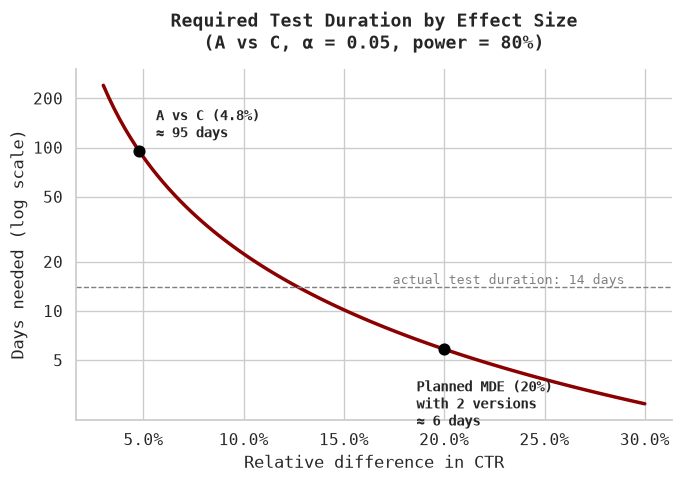

In [30]:
def days_needed(relative_uplift, baseline=ctr_a, n_versions=2):
    """Test duration in days to detect a given relative uplift with the configured alpha and power."""
    es = proportion_effectsize(baseline * (1 + relative_uplift), baseline)
    n = power_analysis.solve_power(effect_size=es, alpha=ALPHA, power=POWER)
    return n / (VISITS_PER_DAY / n_versions)


uplifts = np.linspace(0.03, 0.30, 100)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(uplifts, [days_needed(u) for u in uplifts], color=DARK_RED, linewidth=2.5)

# (uplift, label, text offset in points)
for uplift, label, offset in [(0.20, "Planned MDE (20%)\nwith 2 versions", (-20, -55)),
                              (observed_uplift, f"A vs C ({observed_uplift:.1%})", (12, 10))]:
    d = days_needed(uplift)
    ax.scatter(uplift, d, color="black", s=60, zorder=3)
    ax.annotate(f"{label}\n≈ {d:.0f} days", (uplift, d), xytext=offset,
                textcoords="offset points", fontsize=10, fontweight="bold")

ax.axhline(14, color="grey", linestyle="--", linewidth=1)
ax.text(0.29, 14, "actual test duration: 14 days", ha="right", va="bottom", fontsize=9, color="grey")

ax.set_yscale("log")
ax.set_yticks([5, 10, 20, 50, 100, 200])
ax.yaxis.set_major_formatter(mtick.ScalarFormatter())
ax.set_title("Required Test Duration by Effect Size\n(A vs C, α = 0.05, power = 80%)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Relative difference in CTR")
ax.set_ylabel("Days needed (log scale)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
sns.despine()
plt.tight_layout()
plt.show()

**Interpretation**
- The original design needed ~21,000 visits per version (~12 days with 4 versions). With ~25,000 visits per version,
  the 14-day test was large enough for its purpose: detecting big differences, such as white vs red.
- Detecting the 4.8% difference between A and C would take ~95 days in a dedicated A vs C test (~146 days with Bonferroni).
  Whether that is worth it is a business decision, not a statistical one.

## 7. Additional metrics

Since the post-hoc tests found no single winner, the decision is based on two further metrics (lower is better for both):
- **Drop-off rate:** share of visitors who start a conversion process but don't complete it.
- **Homepage-return rate:** share of visitors who return to the homepage after clicking the button.

Only percentages are available (read from the course chart), and data for Version B was lost due to a collection error.

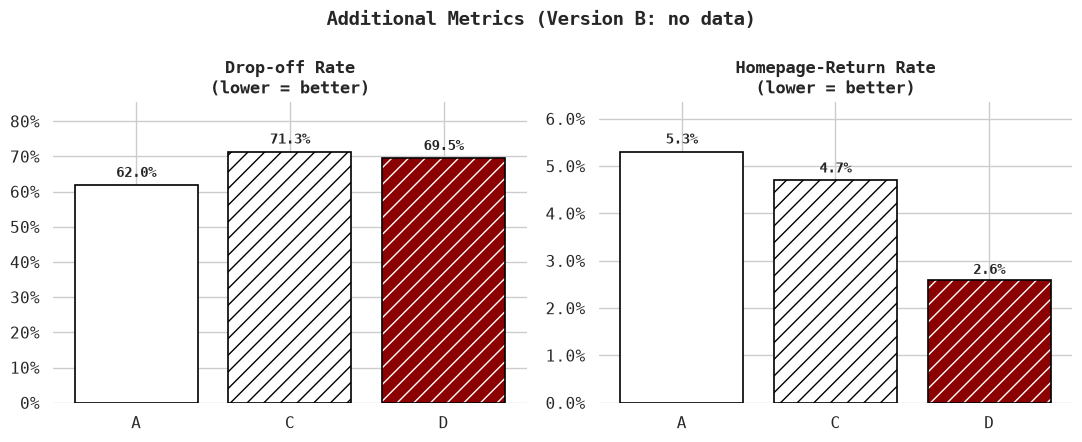

In [31]:
# Approximate values read from the course chart; no data for version B
extra = pd.DataFrame({
    "version":         ["a", "c", "d"],
    "drop_off":        [0.620, 0.713, 0.695],
    "homepage_return": [0.053, 0.047, 0.026],
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, col, title in zip(axes, ["drop_off", "homepage_return"],
                          ["Drop-off Rate", "Homepage-Return Rate"]):
    xs = np.arange(len(extra))
    for x, v, val in zip(xs, extra["version"], extra[col]):
        draw_styled_bar(ax, x, val, v)
        ax.text(x, val * 1.02, f"{val:.1%}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_xticks(xs)
    ax.set_xticklabels([v.upper() for v in extra["version"]])
    ax.set_title(f"{title}\n(lower = better)", fontsize=12, fontweight="bold")
    ax.set_ylim(0, extra[col].max() * 1.2)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    sns.despine(ax=ax, left=True, bottom=True)

fig.suptitle("Additional Metrics (Version B: no data)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Conclusion

**Question:** Which of four button variants on the Eniac homepage achieves the highest click-through rate (CTR)?
The test varied color (white/red) and text ("SHOP NOW"/"SEE DEALS") over 14 days, with roughly 25,000 visits per version.

**Results:**
- **CTR:** A 2.02% · B 1.14% · C 2.12% · D 0.76%
- **Chi-square test across all versions:** highly significant (χ² = 224.02, df = 3, p < 0.001). The versions differ.
- **Pairwise tests with Bonferroni correction (α ≈ 0.0083):** All pairs differ significantly, **except A and C** (p = 0.465).
- **Key finding:** White buttons clearly outperform red ones. For white buttons, the text makes no detectable difference.

**Why A vs. C remains open:** The difference is only 4.8% relative. The test was designed for a minimum detectable effect of 20%.
According to a power analysis, a test of A vs. C alone would need about 95 days (146 days with Bonferroni correction) to detect this difference with 80% power.

**Decision based on additional metrics:**

| Version | Drop-off rate | Homepage-return rate |
|---|---|---|
| A | ~62% | ~5.3% |
| C | ~71% | ~4.7% |
| D | ~69.5% | ~2.6% |

Version A has a clearly lower drop-off rate than C (about 9 percentage points), while C is only slightly ahead on homepage-return rate.
Since the drop-off rate is directly linked to completed purchases, this advantage carries more weight.

**Recommendation:** **Keep Version A (white, SHOP NOW).** Switching to C offers no proven benefit, and red buttons should not be introduced.

**Limitations:**
- Drop-off and homepage-return rates are only available as percentages (read from a chart), so no significance test was possible. No data is available for Version B.
- CTR counts clicks per visit, not individual users.
- According to the snapshot info, Version A was created earlier (2021-09-14) than versions B–D (2021-10-27).